<a href="https://colab.research.google.com/github/gagnagaman/Tziperman/blob/main/greenhouse_workshop_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Greenhouse

### <font color=red> Please use the template below to answer the workshop questions. "XX" indicates places where you need to complete/write code or add a discussion.</font>

## your name: first last

In [ ]:
import numpy as np
from numpy import linalg
import matplotlib.pyplot as plt
import matplotlib
import pickle
from matplotlib.ticker import MultipleLocator
import scipy as scipy
from scipy import optimize
import warnings
import requests

In [ ]:
# URL of the raw pickle file on GitHub
url = "https://raw.githubusercontent.com/gagnagaman/Tziperman/main/greenhouse_variables.pickle"

# Use requests to download the file
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    # Load the data from the downloaded content using pickle
    d = pickle.loads(response.content)

    # print information about each extracted variable:
    for key in list(d.keys()):
        print("extracting pickled variable: name=", key,"; size=", d[key].shape)
        #print("; type=",type(d[key]))
    globals().update(d)
else:
    print(f"Failed to download the pickle file. Status code: {response.status_code}")

extracting pickled variable: name= CO2_monthly_observed ; size= (902,)
extracting pickled variable: name= CO2_monthly_observed_years ; size= (902,)
extracting pickled variable: name= CO2_observed ; size= (175,)
extracting pickled variable: name= CO2_observed_years ; size= (175,)
extracting pickled variable: name= CO2_rcp26 ; size= (101,)
extracting pickled variable: name= CO2_rcp45 ; size= (101,)
extracting pickled variable: name= CO2_rcp6 ; size= (101,)
extracting pickled variable: name= CO2_rcp85 ; size= (101,)
extracting pickled variable: name= CO2_rcp85_years ; size= (101,)
extracting pickled variable: name= OLR_280ppm_CO2_only ; size= (19960,)
extracting pickled variable: name= OLR_560ppm_CO2_only ; size= (19960,)
extracting pickled variable: name= wavenumbers ; size= (19960,)


In [ ]:
import pandas as pd

url2 = 'https://raw.githubusercontent.com/gagnagaman/Tziperman/main/greenhouse_variables.xlsx'

try:
    df_excel = pd.read_excel(url2)
    print("Excel file loaded successfully from URL!")
    display(df_excel.head())
except Exception as e:
    print(f"An error occurred: {e}")

Excel file loaded successfully from URL!


,Unnamed: 0,CO2_monthly_observed,CO2_monthly_observed_years,CO2_observed,CO2_observed_years,CO2_rcp26,CO2_rcp45,CO2_rcp6,CO2_rcp85,CO2_rcp85_years,OLR_280ppm_CO2_only,OLR_560ppm_CO2_only,wavenumbers
0,NaN,285.2,1850.0,285.2,1850.0,368.8650,368.8650,368.8650,368.8650,2000.0,0.000041,0.000041,4.0
1,NaN,285.1,1851.0,285.1,1851.0,370.4675,370.4675,370.4675,370.4675,2001.0,0.000044,0.000044,4.1
2,NaN,285.0,1852.0,285.0,1852.0,372.5225,372.5225,372.5225,372.5225,2002.0,0.000048,0.000048,4.2
3,NaN,285.0,1853.0,285.0,1853.0,374.7600,374.7600,374.7600,374.7600,2003.0,0.000051,0.000051,4.3
4,NaN,284.9,1854.0,284.9,1854.0,376.8125,376.8125,376.8125,376.8125,2004.0,0.000054,0.000054,4.4


In [ ]:
df_excel[['CO2_monthly_observed','CO2_monthly_observed_years']]



,CO2_monthly_observed,CO2_monthly_observed_years
0,285.2,1850.0
1,285.1,1851.0
2,285.0,1852.0
3,285.0,1853.0
4,284.9,1854.0
...,...,...
19955,NaN,NaN
19956,NaN,NaN
19957,NaN,NaN
19958,NaN,NaN


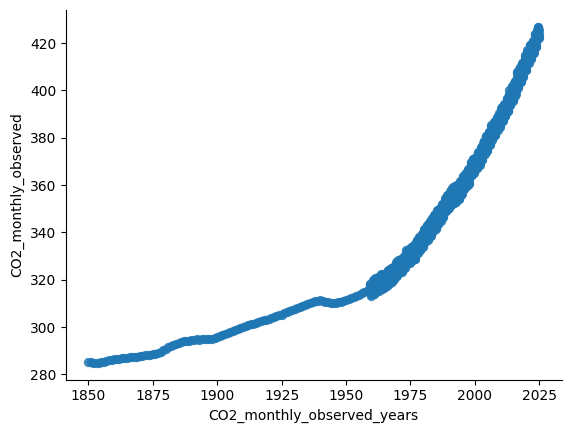

In [ ]:
from matplotlib import pyplot as plt
df_excel.plot(kind='scatter', y='CO2_monthly_observed', x='CO2_monthly_observed_years', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

### Explanation of variables:

**CO2_observed** is a time series of observed CO$_2$, as a function of time in years given by variable **CO2_observed_years**.

Similarly, **CO2_rcp*** are time series of projected CO$_2$ according to different RCP scenarios.

**OLR_280ppm_CO2_only** is the top-of-the-atmopshere outgoing longwave radiation, with 280 ppm of CO2, as function of **wavenumbers**, that are given by the variable of that name. similarly for **OLR_560ppm_CO2_only**.

<Axes: title={'center': 'Atmospheric spectrum with two different CO$_2$ levels'}, xlabel='wavenumbers'>

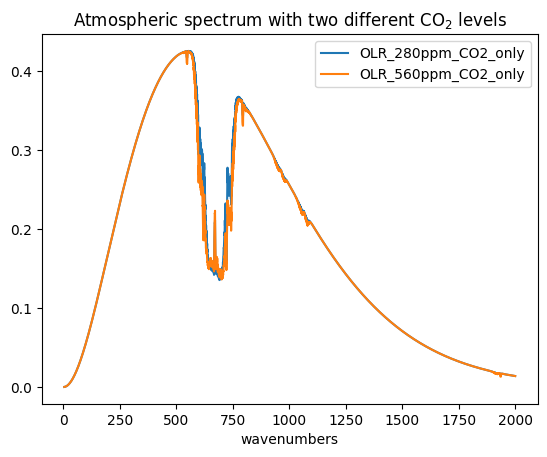

In [13]:
df_w=df_excel[['wavenumbers','OLR_280ppm_CO2_only','OLR_560ppm_CO2_only']]
df_w.plot(x='wavenumbers',title='Atmospheric spectrum with two different CO$_2$ levels')

In [15]:
df_w = df_excel[['wavenumbers','OLR_280ppm_CO2_only','OLR_560ppm_CO2_only']].copy()
df_w['diff_280_560'] = df_w['OLR_280ppm_CO2_only'] - df_w['OLR_560ppm_CO2_only']

<Axes: title={'center': 'Difference in thermal radiation absorbtion '}, xlabel='wavenumbers'>

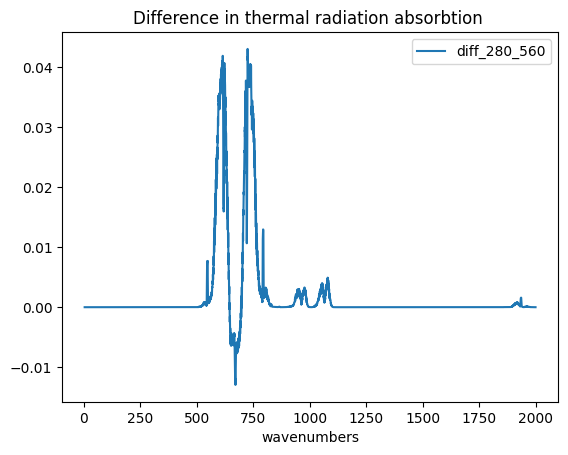

In [16]:
df_w.plot(x='wavenumbers', y='diff_280_560', kind='line',title='Difference in thermal radiation absorbtion ')

## 1) Observed and projected increase in greenhouse gasses:

Plot CO$_2$ since 1850, superimpose the predicted CO$_2$ concentration from the RCP8.5 (sometimes referred to as ``business as usual'') scenario from a previous IPCC report going to 2100.

In [ ]:
fig = plt.figure(1,figsize=(3,3),dpi=200)
#plt.plot(XX,XX,lw=3,color="blue",label="observed CO2")
#plt.plot(XX,XX,lw=1,color="red",label="Projected rcp8.5 CO2")
plt.legend()
#plt.xlabel(XX)
plt.ylabel('CO$_2$ Concentration (ppm)');

##  2)  Energy balance model:

(a) Calculate  the downwelling LW and absorbed SW at the surface in the two-layer model, using an albedo of 0.25, an atmospheric emissivity of 0.8, and searching the web for the other constants.

In [ ]:
# constants:
S0 = XX  # solar constant
albedo = XX # Albedo
epsilon = XX # emissivity
sigma = XX  # stefan-boltzmann constant


# calculate atmospheric temperature T_a:
T = XX
T_a=XX
print("T,T_a=",T,T_a)
# answer:
LW_down=XX
SW_net=XX
print("LW_down=",LW_down,",SW_net=",SW_net)

(b) Modify the 2-layer energy balance model to take into account the absorption of a fraction $\Delta=0.15$ of the downward shortwave radiation by the atmosphere. Calculate the resulting temperatures, compare to the case of $\Delta=0$. Use the results to discuss how increased atmospheric aerosol concentrations due to industrial emissions, which increases SW absorption, can mask the surface warming due to CO$_2$ increase.

## Solution
The new energy balance equation for the surface is:
\begin{equation}\frac{S_0}{4}XX(1-\alpha) +\epsilon \sigma T_a^4 = \sigma T^4\end{equation}

The new energy balanance equation for the atmosphere is:
\begin{equation}XX + \epsilon \sigma T^4 = 2\epsilon \sigma T_a^4 \end{equation}

where $T$ is the surface temperature, and $T_a$ is the atmospheric temperature. Substituting the second equation into the first yields:
\begin{equation} XX = \sigma T^4\end{equation}
Solving for $T$ yields:
\begin{equation}T = \left[\frac{XX}{\sigma(1-\frac{\epsilon}{2})} \right]^{1/4} \end{equation}

In [ ]:
# evaluating the solution numerically:

Delta = .15
T = (XX)**(1/4)
print('T = ', T)
T_a = XX
print('T_a = ',T_a)

### Discussion:

XX

(c) Consider an abrupt CO$_2$ doubling corresponding to the transition from panel a of Figure 2.4 to panel b. Considering the response of an atmosphere with a continuous vertical temperature profile of a prescribed lapse rate, calculate the increase in the emission height corresponding to an increase in radiative forcing by 4 W\,m$^{-2}$ assuming a lapse rate of 6.5 K/km.

In [ ]:
# first, the temperature decrease required to lower the LW by 4 W/m^2:

# The emission height temperature is found by the balance of outgoing
# long-wave radiation from the emission height balancing the incoming solar
# radiation minus the refelected part.
T=XX
# Calclate the right value of DeltaT that leads to a 4 W/m^2 change in F:
DeltaT=XX
print("DeltaT=",DeltaT)
# check that radiative forcing changed as expected:
print("DeltaF=",sigma*(XX)**4-sigma*XX**4)

# now, given a lapse rate of 6.5 K/km, this implies the following change in emission height:
print("change in emission height (m):",XX*1000)

## 3) Radiative forcing

  (a) Explain the upper and lower boundaries of the trapezoidal gap in the shape of the OLR curve around 600-800 cm$^{-1}$ (Figure 2.5b) due to CO$_2$ absorption, in terms of the emission height.
  
  (b) Plot the OLR in a standard atmosphere in the presence of 280 and 560 ppm CO2, ignoring all other greenhouse gasses.
  
  (c) Estimate the radiative forcing of 280 ppm of CO$_2$ by fitting a trapezoid to your plotted OLR curve and calculating its area.
  
  (d) Calculate the radiative forcing due to a doubling of the CO$_2$ from the preindustrial value of 280 ppm, by integrating over the difference of the two OLR curves.

## Solutions
a) XX

In [ ]:
# (b)

# Read in pickle data of the two OLR curves and plot
fig = plt.figure(1,figsize=(6,4),dpi=300)
ax = plt.gca()
plt.plot(XX,XX,lw=1,color="blue",label="280 ppm")
plt.plot(XX,XX,lw=1,color="red",ls='--',label="560 ppm")
plt.xlabel('Wavenumber (cm$^{-1}$)')
plt.ylabel('OLR (W/[m$^2$cm$^{-1}$])')

# plot tickmarks and grid
ax.xaxis.set_minor_locator(MultipleLocator(50))
ax.yaxis.set_minor_locator(MultipleLocator(.02))

# title and legend:
plt.title("OLR as function of wavenumber")
plt.grid(which='both',lw=0.25)
plt.legend();
plt.show();

c) We choose the top of the trapezoid as XX. This gives a total height of the trapezoid as XX W/m$^2$. The bottom width is about XX cm$^{-1}$ and the top width is about XX cm$^{-1}$. Thus using the formula for a trapezoid, $A = H * (Base1 + Base2)/2$ we get a radiative forcing of  XX W/m$^2$.

d) The integral over the OLR curve tells you the total outgoing longwave radiation. The difference between the total OLR with 280ppm and 560ppm gives you the radiative forcing of doubling CO2.

In [ ]:
# approximate the integral by a sum:
Delta_wavenumber = wavenumbers[1] - wavenumbers[0]
RF = Delta_wavenumber*np.sum(XX-XX)
print("Radiative Forcing: "+str(round(RF,3))+' W/m^2')

## 4) Logarithmic dependence

if a doubling of CO$_2$ from 280 ppm to 560 leads to, say, 3 degree warming, what warming do you expect at an equivalent CO$_2$ mixing ratio of 500 ppm? Discuss the fact that warming so far is just over 1.2 degree.

In [ ]:
# if the warming for CO2 doubling is 3 degree, we can write the warming as
CO2=560
DeltaT=XX
print("CO2=",CO2,", DeltaT=",DeltaT)
CO2=500
DeltaT=XX
print("CO2=",CO2,", DeltaT=",DeltaT)

**Discussion:** XX

## 5) Global warming potential:

Suppose the GWP of methane for a time horizon of 100 yr is 34. Assume methane concentration decays exponentially over 12.4 yr (so the decay function is $e^{-t/12.4}$) while that of CO$_2$ decays over 200 yr (e.g., due to dissolution in the ocean; note that while such a timescale is often used, the actual expected residence time of anthropogenic CO$_2$ in the climate system is thousands of years.) (a) How much more efficient is a kilogram of methane at absorbing LW radiation than a kilogram of CO$_2$? (b) Discuss the difference between GWP and absorption efficiency. (c) What is the methane GWP for a time horizon of 500 yr? Explain.

(a) Reformulate the GWP equation to solve for $a_x/a_r$.

XX

Therefore, we can conclude that methane molecules absorbs more than XX times more strongly than CO$_2$.

(b) XX discuss

(c) XX

## 6) Water vapor feedback to increased CO$_2$:
    
Modify the energy balance model equations (2.2) to include the effects of increasing water vapor and calculate the warming as a function of CO$_2$ with and without this feedback as follows. Assume the atmospheric emissivity depends on CO$_2$ and moisture $q(T_a)$ as $\epsilon({\mathrm{CO}}{{}_2},q(T_a)) =\epsilon_0+A\log_2({\mathrm{CO}}{{}_2}/280)+B\log_2({q(T_a)/q(T_{a0})})$, where $\epsilon_0=0.75$ and $T_{a0}$ is the atmospheric temperature for CO$_2$=280 ppm, and that the atmospheric relative humidity is the same before and after the CO$_2$ change. Find values for $A$ and $B$ such that the warming due to CO$_2$ doubling only is 2$^\circ$C, and due to both feedbacks is 4$^\circ$C. Plot $T_a({\mathrm{CO}}{{}_2})$ for CO$_2$ in the range of 200 to 800 ppm with and without the water vapor feedback.

In [ ]:
# constants:
albedo = 0.32
epsilon_0 = 0.75
Pa=500 # mid-atmospheric pressure

# atmospheric temperature at 280 ppm:
T_a0 = XX

# first, find what changes to the emissivity are needed to cause the suggested warmings:
# Rerun this cell with different values of A until the temperature rise due to CO2 doubling alone is 2 K:
A = XX  # change due to CO2 doubling
T_a_2XCO2 = XX # energy balance solution in terms of an emissivity of epsilon0+A
print("T_a0=",T_a0,", T_a_2XCO2=", T_a_2XCO2)

Now find B:

In [ ]:
# help functions: emissivity and saturation specific humidity:
def emissivity(CO2,T_a,A,B):
    # emisivity a function of CO2 and atmc temperature
    epsilon=XX
    return epsilon

def q_sat(T,P):
    # saturation specific humidity (g water vapor per g moist air):
    # inputs:
    # T: temperature, in Kelvin
    # P: pressure, in mb
    R_v = XX # Gas constant for moist air = 461 J/(kg*K)
    R_d = XX # Gas constant 287 J K^-1 kg^-1
    TT = XX # Kelvin to Celsius
    qw=
    return qw

# the desired temperature with both feedbacks as specified in the question:
T_a_2XCO2_water_vapor = T_a_2XCO2+2;

# now calculate and plot the temperature as a function of the coefficient B to find
# when it reaches the assumed warming:

Brange = np.arange(XX)
Trange=XX # a array with zeros of the same dimension of Brange, for
          # temeprature as a function of B
i=-1
for B in Brange:
    i=i+1
    epsilon = XX
    Trange[i]=XX # energy balance solution with appropriate emissivity

# Plot:
fig = plt.figure(figsize=(6,3),dpi=300)
plt.plot(XX \
         , label='temperature with water vapor feedback')
plt.plot(XX \
         , label='T_a_2XCO2_water_vapor')
plt.legend()
plt.xlabel('XX')
plt.ylabel('XX')
plt.grid(lw=0.25)
plt.title('XX');
plt.show();

Use A,B to solve for Ta and plot with and without the water vapor feedback:

In [ ]:
# from the plot, we conclude that
B=XX
# results in the desired temperature response to CO2 and water vapor.

# Now plot the temperature with and without the water vapor
# feedback as a function of CO2.

# helper function to solve for T_a when emissivity depends on it:
def solve_for_T_a(T_a):
    # calculate T_a-((S0/4)*(1-albedo)/(sigma*(2-epsilon(CO2,T_a))))**(1/4),
    # to be called by scipy.optimize.fsolve in order to find a solution for T_a that satifies
    # this equation
    equation=XX
    return equation


# range of CO2 to consider:
CO2_range=np.arange(XX)
# Prepare arrays for atmospheric temperature response to CO2
# and to both CO2 and water vapor:
Ta_CO2_only=XX
Ta_both=XX

i=-1
for CO2 in CO2_range:
    i=i+1
    B=0; epsilon=emissivity(XX,XX,XX,XX)
    Ta_CO2_only[i]=XX
    B=XX # from previous cell
    x0=XX # initial guess
    T_a=optimize.fsolve(solve_for_T_a,x0,args=(A,B))
    Ta_both[i]=T_a


# Plot Ta vs CO2 with and without water vapor feedback:
fig = plt.figure(figsize=(6,3),dpi=300)
plt.plot(CO2_range, XX, color = 'orange', label='CO$_2$ only')
plt.plot(CO2_range, XX, color = 'red', label='CO$_2$ and water vapor')
plt.legend()
plt.xlabel('XX')
plt.ylabel('XX')
plt.grid(lw=0.25)
plt.title('XX');
plt.show();